In [473]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

<!--  -->

In [474]:
df = pd.read_csv("laptop.csv")

In [475]:
#checking shape of the data
df.shape

(1303, 13)

In [476]:
#checking columns
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Company', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price'],
      dtype='object')

<!-- ### **Data Cleaning** -->

<!-- There is column named "Unnamed: 0", "Unnamed: 0.1" which is a unnecessary data for this project. So we can safely drop the column from the dataset. -->

In [477]:
#removing unuseful columns
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis = 1)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [478]:
#checking null values
df.isnull().sum()

Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [479]:
#treating null values
df = df[df['Weight'] != '?'].dropna()

In [480]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [481]:
df.dtypes

Company              object
TypeName             object
Inches               object
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

In [482]:
df[df['Inches'] == '?']
#removing data with ? value
df = df[df['Inches'] != '?'].dropna()
#convert Inches column as float type
df['Inches'] = df['Inches'].astype(float)

In [483]:
#checking if data have ? on any place
df[df.values == '?']
#removing data with ? value
df = df[df['Memory'] != '?'].dropna()

In [484]:
df[df.values == '?']

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price


In [485]:
#convert Ram column as int type
df['Ram'] = df['Ram'].str.replace('GB','').astype(int)

In [486]:
df.dtypes

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

In [487]:
#convert Weight column as float type
df['Weight'] = df['Weight'].str.replace('kg','').astype(float)

In [488]:
df.dtypes

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price               float64
dtype: object

In [489]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


<!-- # Exploratory Data Analysis -->

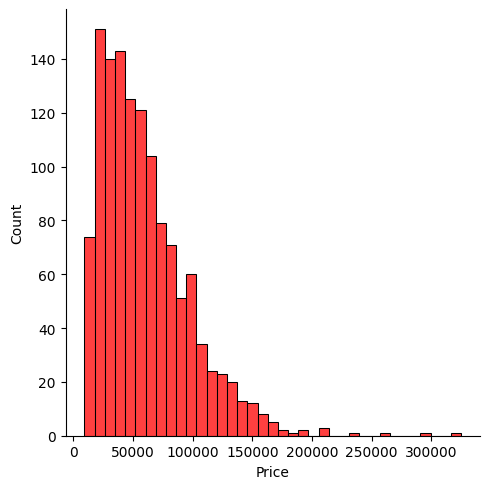

In [490]:
# viewing the distribution of the price column

sn.displot(df['Price'],color='red')

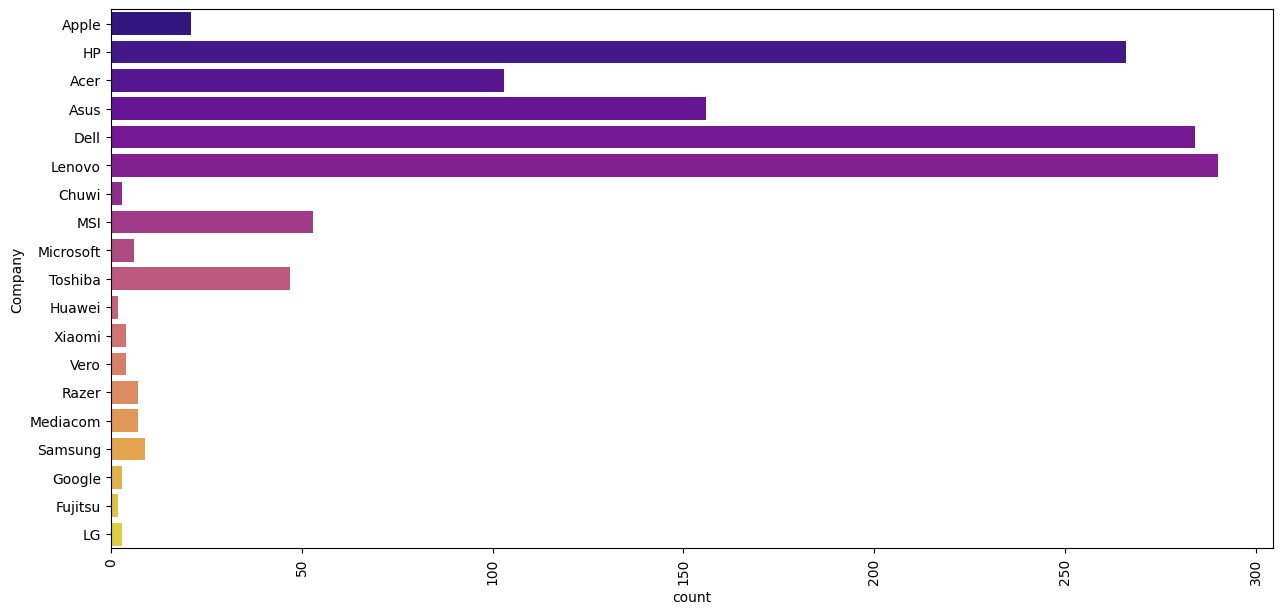

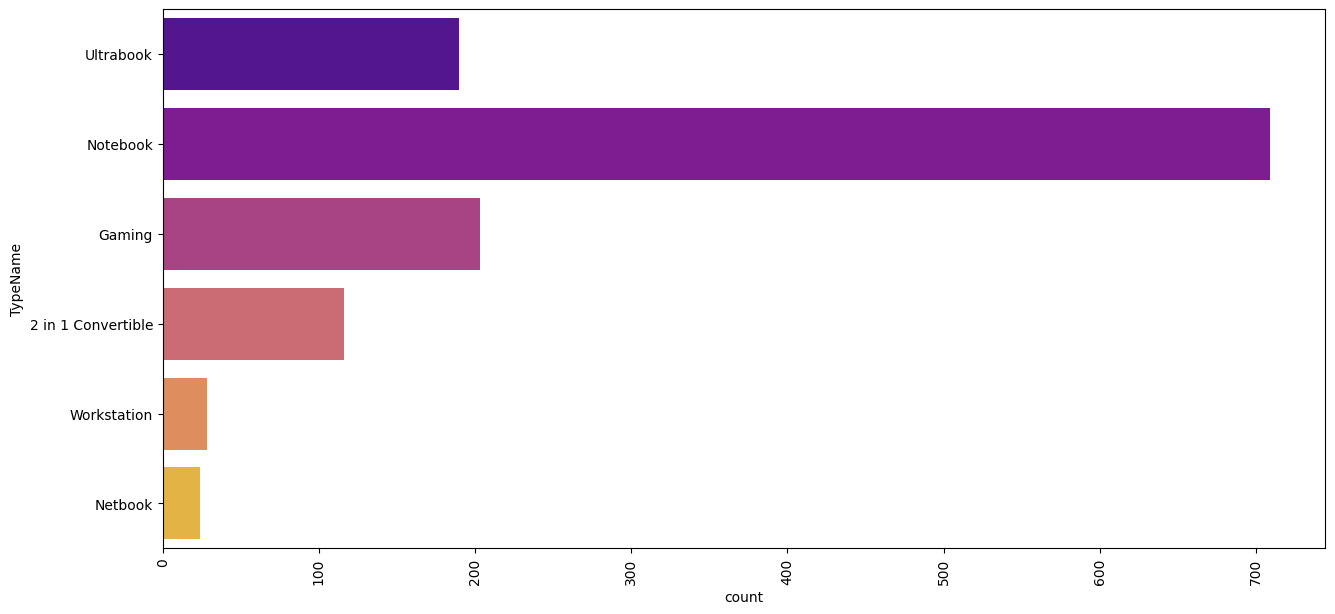

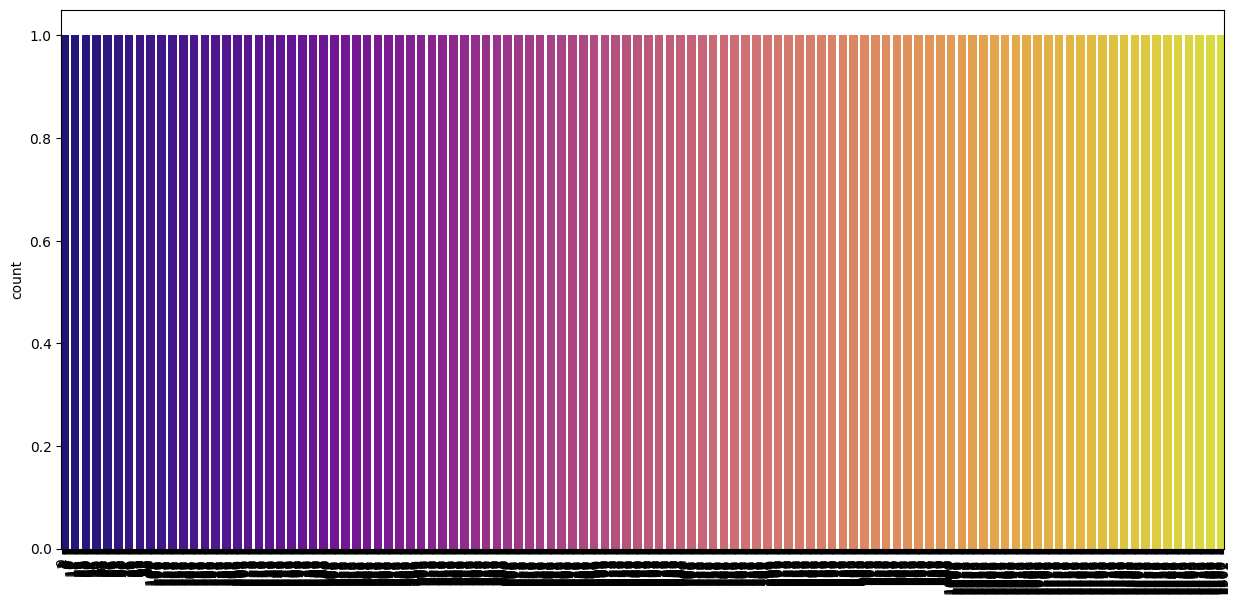

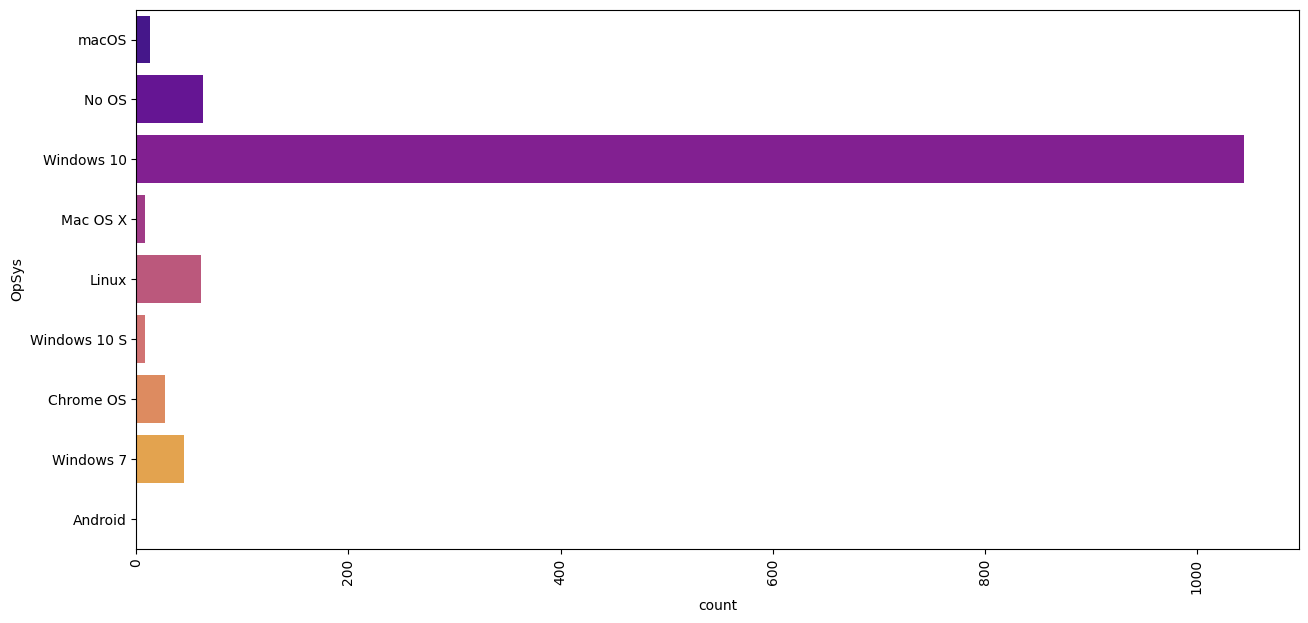

In [491]:
# plotting countplots for the categorical variables

def drawplot(col):
    plt.figure(figsize=(15,7))
    sn.countplot(df[col], palette='plasma')
    plt.xticks(rotation='vertical')
    
to_view = ['Company', 'TypeName', 'Ram', 'OpSys']
for col in to_view:
    drawplot(col)

# Question: Does the brand of the laptop significantly influence its price?

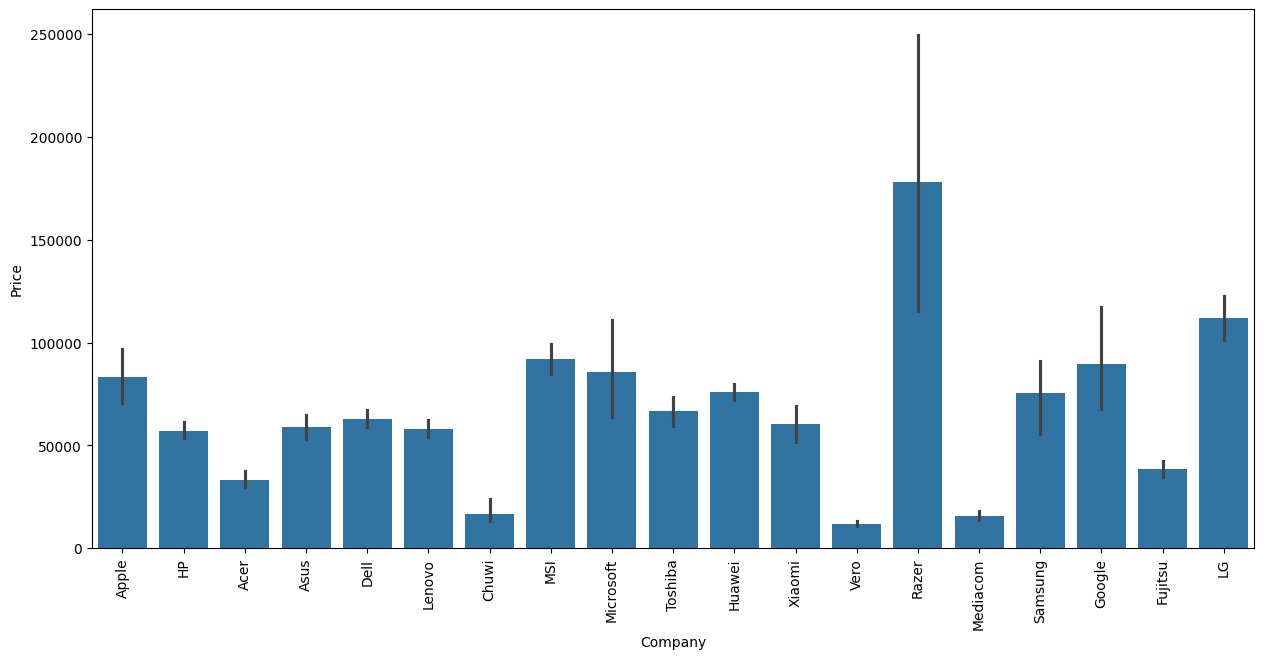

In [ ]:
# average price for each of the laptop brands

plt.figure(figsize=(15,7))
sn.barplot(x = df['Company'],y = df['Price'])
plt.xticks(rotation = 'vertical')
plt.show()

We can say that as per company the price of the laptop vary

# Insight on Type of Laptop

(array([  0., 100., 200., 300., 400., 500., 600., 700., 800.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700'),
  Text(800.0, 0, '800')])

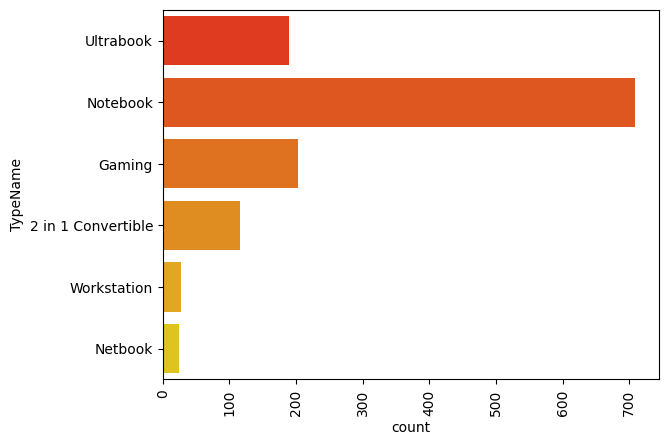

In [493]:
# various types of laptop

sn.countplot(df['TypeName'],palette='autumn')
plt.xticks(rotation = 'vertical')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Ultrabook'),
  Text(1, 0, 'Notebook'),
  Text(2, 0, 'Gaming'),
  Text(3, 0, '2 in 1 Convertible'),
  Text(4, 0, 'Workstation'),
  Text(5, 0, 'Netbook')])

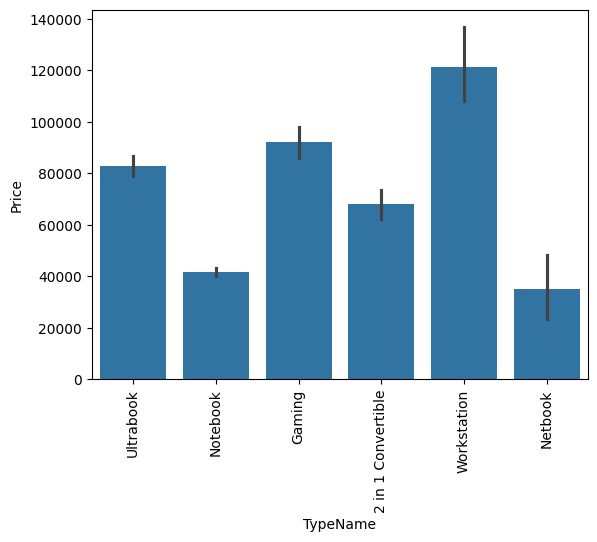

In [494]:
# laptop type and variation about the price

sn.barplot(x = df['TypeName'],y = df['Price'])
plt.xticks(rotation = 'vertical')

<Axes: xlabel='Inches', ylabel='Price'>

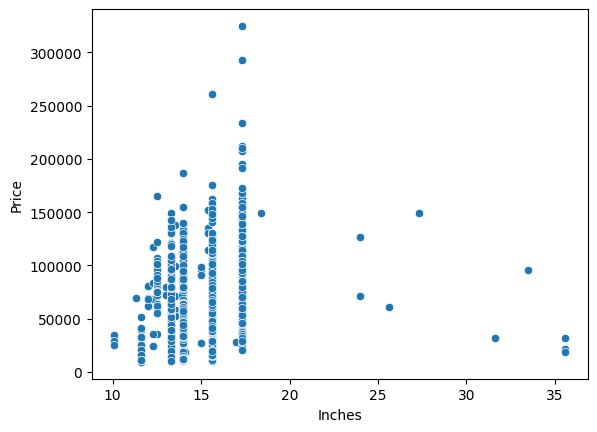

In [495]:
# variation of inches towards the price

sn.scatterplot(x = df['Inches'],y = df['Price'])

<!-- **For the Screen Resolution column we have many types of Screen Resolutions out there as shown as Touch Screen and Normal and IPS Panel are the 3 parts on basis of which we can segregate the things** -->

In [496]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                492
1366x768                                         274
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         52
Full HD / Touchscreen 1920x1080                   45
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  14
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                9
IPS Panel 1366x768                                 7
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              6
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [497]:
df['ScreenResolution']

0               IPS Panel Retina Display 2560x1600
1                                         1440x900
2                                Full HD 1920x1080
3               IPS Panel Retina Display 2880x1800
4               IPS Panel Retina Display 2560x1600
                           ...                    
1298     IPS Panel Full HD / Touchscreen 1920x1080
1299    IPS Panel Quad HD+ / Touchscreen 3200x1800
1300                                      1366x768
1301                                      1366x768
1302                                      1366x768
Name: ScreenResolution, Length: 1270, dtype: object

In [498]:
# creating a new col, touchscreen if the value is 1 that laptop is touch screen 

df['TouchScreen'] = df['ScreenResolution'].apply(lambda element:1
                                                      if 'Touchscreen' in element else 0)

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0


<Axes: ylabel='count'>

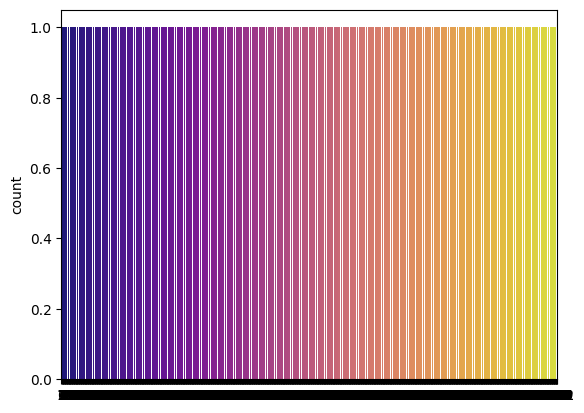

In [499]:
sn.countplot(df['TouchScreen'], palette='plasma')

<!-- Touch screen on comparison with price of laptop -->

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

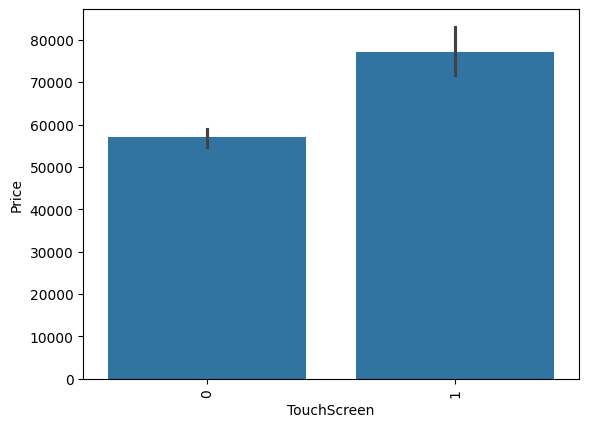

In [500]:


sn.barplot(x = df['TouchScreen'],y = df['Price'])
plt.xticks(rotation = 'vertical')


In [501]:
# creating a new col named IPS, does the laptop have IPS facility or not

df['IPS'] = df['ScreenResolution'].apply(
    lambda element:1 if "IPS" in element else 0
)
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
697,Asus,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.20,35644.3200,1,0
707,Lenovo,Workstation,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Nvidia Quadro M520M,Windows 7,2.18,98834.4000,0,0
709,HP,Notebook,17.3,IPS Panel Full HD 1920x1080,AMD A10-Series 9620P 2.5GHz,6,2TB HDD,AMD Radeon 530,Windows 10,2.71,34898.9328,0,1
216,Lenovo,Notebook,17.3,1600x900,Intel Core i5 7200U 2.5GHz,8,1TB HDD,Nvidia GeForce GTX 940MX,No OS,2.80,31381.9200,0,0
212,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,500GB HDD,Intel HD Graphics 520,No OS,2.10,18594.7200,0,0


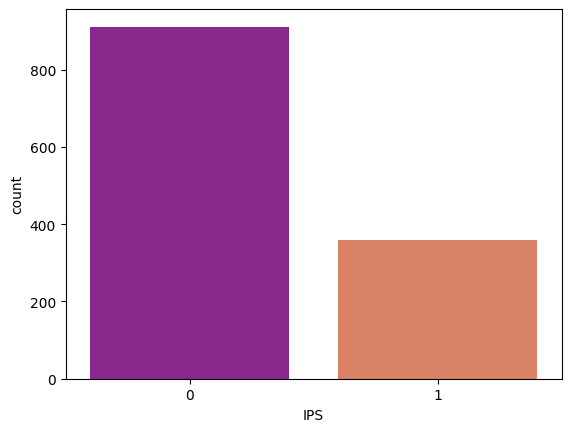

In [502]:
#visualizing the IPS column
sn.countplot(x='IPS', data=df, palette='plasma')
plt.show()


<Axes: ylabel='count'>

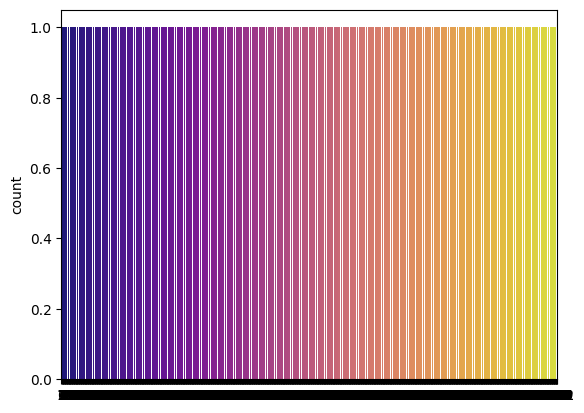

In [503]:
sn.countplot(df['IPS'], palette='plasma')

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

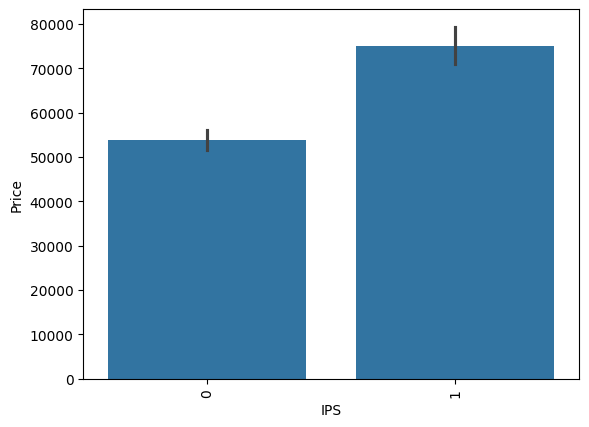

In [504]:
# price variation with respect to the IPS col

sn.barplot(x = df['IPS'], y = df['Price'])
plt.xticks(rotation = 'vertical')

<!-- # Extracting the X Resolution and the Y Resolution -->

In [513]:
# 2560x1440 -----> <before>x<after>
split_df = df['ScreenResolution'].str.lower().str.strip().str.split('x', n=1, expand=True)
df['X_res'] = split_df[0]
df['Y_res'] = split_df[1]
'''
We will split the text at the "x" letter and seperate the 2 parts. 
From this we can observe that one of the col is Y res, we need to do
some feature engineering on the X res col
'''

split_df = df['ScreenResolution'].str.split('x',n = 1,expand=True)
split_df.head()

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600


In [514]:
# split_df = df['ScreenResolution'].str.split('x',n = 1,expand=True)

df['X_res'] = split_df[0]
df['Y_res'] = split_df[1]
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,IPS Panel Retina Display 2560,1600


In [516]:
df['X_res'] = df['X_res'].str.replace(',','').str.findall(r'(\d+.?\d+)').apply(lambda x:x[0])
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


<!--  -->

In [517]:
df['X_res'].unique()

array(['2560', '1440', '1920', '2880', '1366', '2304', '3200', '2256',
       '3840', '2160', '1600', '2736', '2400'], dtype=object)

In [518]:
df['X_res'] = df['X_res'].astype('int')
df['Y_res'] = df['Y_res'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1270 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   object 
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   float64
 3   ScreenResolution  1270 non-null   object 
 4   Cpu               1270 non-null   object 
 5   Ram               1270 non-null   int64  
 6   Memory            1270 non-null   object 
 7   Gpu               1270 non-null   object 
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   float64
 10  Price             1270 non-null   float64
 11  TouchScreen       1270 non-null   int64  
 12  IPS               1270 non-null   int64  
 13  X_res             1270 non-null   int64  
 14  Y_res             1270 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 158.8+ KB


In [519]:
#make a copy of data frame for future use
df1 = df.copy()

In [520]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900


In [521]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r'[^\x00-\x7F]', '', regex=True)  # removes non-ASCII


In [522]:
df.columns = df.columns.str.strip().str.replace(r'[^\x00-\x7F]', '', regex=True)
print(df.columns.tolist())  # check the actual column names


['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'TouchScreen', 'IPS', 'X_res', 'Y_res']


In [523]:
print(df['X_res'].dtype)

int64


In [524]:
df['X_res']

0       2560
1       1440
2       1920
3       2880
4       2560
        ... 
1298    1920
1299    3200
1300    1366
1301    1366
1302    1366
Name: X_res, Length: 1270, dtype: int64

In [525]:
df['X_res'] = df['X_res'].astype('int')
df['Y_res'] = df['Y_res'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1270 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   object 
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   float64
 3   ScreenResolution  1270 non-null   object 
 4   Cpu               1270 non-null   object 
 5   Ram               1270 non-null   int64  
 6   Memory            1270 non-null   object 
 7   Gpu               1270 non-null   object 
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   float64
 10  Price             1270 non-null   float64
 11  TouchScreen       1270 non-null   int64  
 12  IPS               1270 non-null   int64  
 13  X_res             1270 non-null   int64  
 14  Y_res             1270 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 158.8+ KB


In [526]:
df.dtypes[df.dtypes == 'object']

Company             object
TypeName            object
ScreenResolution    object
Cpu                 object
Memory              object
Gpu                 object
OpSys               object
dtype: object

<Axes: >

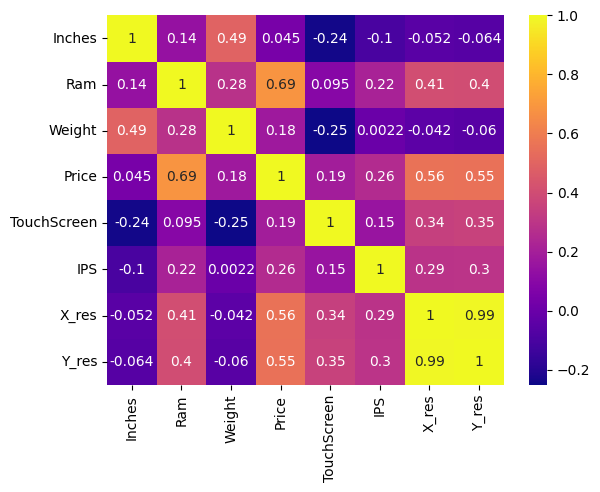

In [527]:
sn.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='plasma')

In [528]:
#checking correlation with price column
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df.select_dtypes(include='number').corr()['Price'].sort_values(ascending=False)


Price          1.000000
Ram            0.687176
X_res          0.558245
Y_res          0.554788
IPS            0.256502
TouchScreen    0.190070
Weight         0.176689
Inches         0.045028
Name: Price, dtype: float64

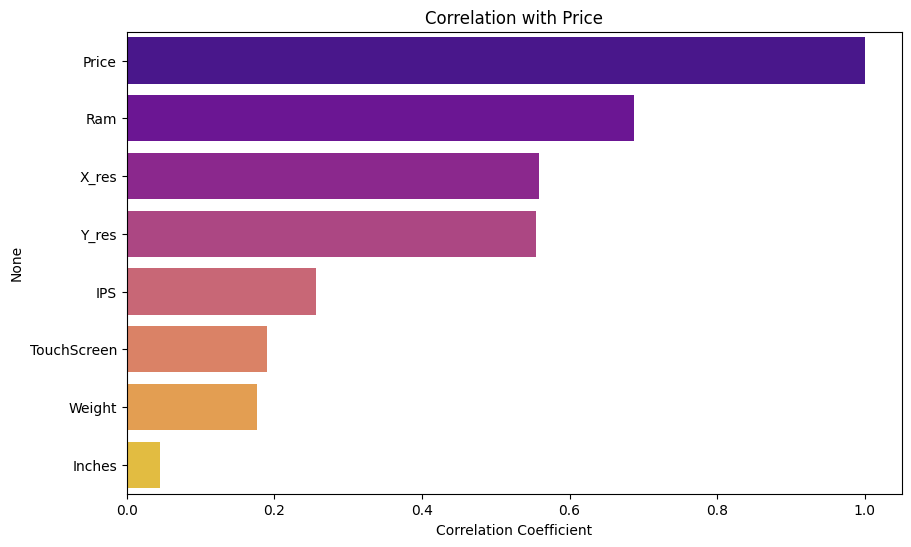

In [530]:
#visualizing correlation with price
plt.figure(figsize=(10, 6))
df_corr = df.select_dtypes(include='number').corr()['Price'].sort_values(ascending=False)
sn.barplot(x=df_corr.values, y=df_corr.index, palette='plasma')
plt.title("Correlation with Price")
plt.xlabel("Correlation Coefficient")
plt.show()


<!-- **From the correlation plot we observed that as the X_res and Y_res is increasing,the price of the laptop is also increasing,so `X_res and Y_res` are positively correlated and they are giving much information,so that is the reason why i had splitted `Resolution` column into `X_res and Y_res` columns respectively** -->

<!-- **So to make things good,we can create a new column named `PPI{pixels per inch}`,now  as we saw from the correlation plot that the `X_res and Y_res` are having much collinearity,so why not combine them with `Inches` which is having less collinearity,so we will combine them as follows ↓,so here is the formula of how to calculate `PPI` {pixels per inch}** -->

<!-- $$
PPI(pixels per inch) = \frac{\sqrt{X_resolution^2+Y_resolution^2}}{inches}
$$ -->

In [531]:
# Ensure X_res, Y_res, and Inches are numeric
df['X_res'] = pd.to_numeric(df['X_res'], errors='coerce')
df['Y_res'] = pd.to_numeric(df['Y_res'], errors='coerce')
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')

# Now safely calculate PPI
df['PPI'] = ((df['X_res']**2 + df['Y_res']**2)**0.5 / df['Inches'])


In [532]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940


<!-- **So we observe from the correlation data that the PPI is having good correlation, so we will be using that, as that is a combination of 3 features and that gives collective results of 3 columns, so we will drop Inches, X_res, Y_res as well** -->

In [534]:
df.drop(columns=['ScreenResolution', 'Inches', 'X_res', 'Y_res'],inplace=True)
df.head()

KeyError: "['ScreenResolution', 'Inches', 'X_res', 'Y_res'] not found in axis"

In [535]:
df.shape

(1270, 12)

In [536]:
df.columns

Index(['Company', 'TypeName', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price', 'TouchScreen', 'IPS', 'PPI'],
      dtype='object')

<!-- # Treating CPU Column -->

In [537]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       183
Intel Core i7 7700HQ 2.8GHz      141
Intel Core i7 7500U 2.7GHz       127
Intel Core i7 8550U 1.8GHz        71
Intel Core i5 8250U 1.6GHz        68
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

<!-- **Most common processers are made by Intel, so we will be clustering their processers into different categories like i5, i7,other, now other means the processers of Intel which do not have i3, i5 or i7 attached to it, they are completely different so that's the reason I will cluster them into other and other category is AMD which is different category in whole** -->

<!-- **So if we observe we need to extract the first 3 words of the CPU column, as the first 3 words of every row under the CPU col is the type of the CPU, so we will be using them.** -->

In [538]:
df['CPU_name'] = df['Cpu'].apply(lambda text:" ".join(text.split()[:3]))
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [539]:
'''
As mentioned earlier, if we get any of the Intel versions we will return
them as it is, but if we get any other processer we will first check 
whether is that a variant of the intel? or not if yes, then we will tag
it as "Other Intel Processer" else we will say it as "AMD Processer".

'''

def processertype(text):
    
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processer'

        else:
            return 'AMD Processer'
        
df['CPU_name'] = df['CPU_name'].apply(lambda text:processertype(text))
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [540]:
df.tail()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
1298,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.64,1,1,157.350512,Intel Core i7
1299,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.72,1,1,276.053530,Intel Core i7
1300,Lenovo,Notebook,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12,0,0,111.935204,Other Intel Processer
1301,HP,Notebook,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.92,0,0,100.454670,Intel Core i7
1302,Asus,Notebook,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.32,0,0,100.454670,Other Intel Processer


In [541]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
720,Lenovo,Ultrabook,Intel Core i7 6500U 2.5GHz,64,512GB SSD,Intel HD Graphics 520,Windows 10,1.17,89864.1792,0,1,209.800683,Intel Core i7
1206,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.91,30849.1200,0,0,100.454670,Intel Core i5
651,Acer,Gaming,Intel Core i5 7300HQ 2.5GHz,8,1TB HDD,Nvidia GeForce GTX 1050,Linux,2.40,37775.5200,0,0,141.211998,Intel Core i5
223,HP,Notebook,Intel Core i5 8250U 1.6GHz,8,1TB HDD,Intel UHD Graphics 620,Windows 10,2.10,42304.3200,0,0,141.211998,Intel Core i5
77,Dell,Notebook,Intel Core i7 8550U 1.8GHz,8,128GB SSD + 1TB HDD,Intel UHD Graphics 620,Windows 10,2.02,45554.4000,0,0,141.211998,Intel Core i7


(array([  0., 100., 200., 300., 400., 500., 600.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600')])

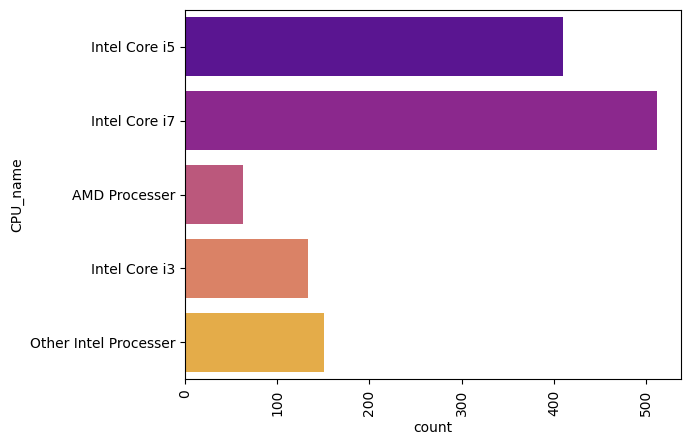

In [542]:
sn.countplot(df['CPU_name'],palette='plasma')
plt.xticks(rotation = 'vertical')

<!-- Visualizing the CPU name with respect to the price -->

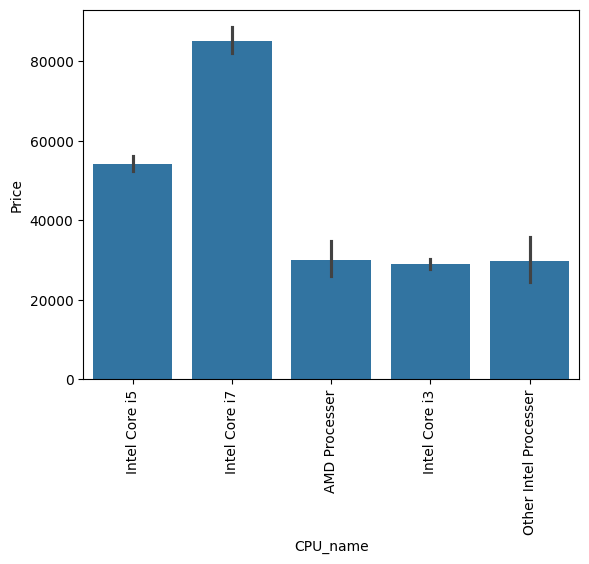

In [543]:
sn.barplot(x='CPU_name', y='Price', data=df)
plt.xticks(rotation='vertical')
plt.show()


In [544]:
# dropping the cpu column 
df.drop(columns=['Cpu'],inplace=True)
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [545]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
735,Lenovo,Notebook,4,1TB HDD,Intel HD Graphics 620,Windows 10,1.85,41505.12,0,0,141.211998,Intel Core i7
834,Lenovo,Notebook,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.32,87912.00,0,1,157.350512,Intel Core i5
403,Acer,Notebook,8,256GB SSD,Nvidia GeForce GTX 1050,Linux,2.50,46833.12,0,0,141.211998,Intel Core i7
1222,HP,Notebook,6,1TB HDD,AMD Radeon 530,Windows 10,2.10,28185.12,0,0,141.211998,AMD Processer
259,Lenovo,2 in 1 Convertible,8,512GB SSD,Nvidia GeForce GTX 1050M,Windows 10,2.00,90522.72,1,1,141.211998,Intel Core i7


<!-- # Analysis on RAM column -->

<Axes: ylabel='count'>

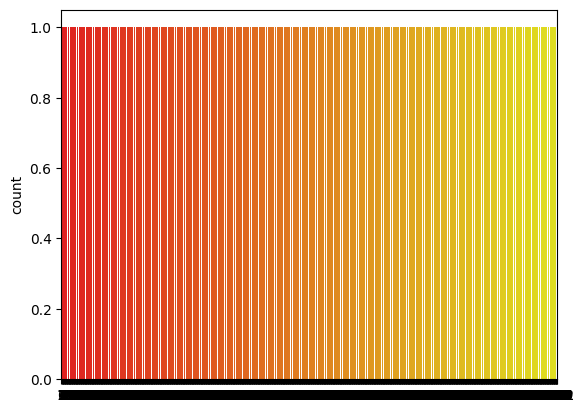

In [546]:
sn.countplot(df['Ram'],palette='autumn')

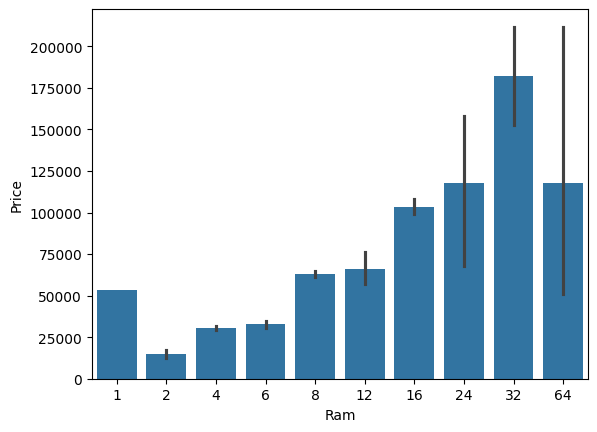

In [547]:
sn.barplot(x='Ram', y='Price', data=df)
plt.show()


<!-- **ABOUT THE MEMORY COLUMN** -->

<!-- **We will seperate the Type of memory and the value of it, just similar to the one which is done in the previous part** -->

<!-- **This part invloves things which are needed to be done in steps, so here we do not have the memory as a complete we have it in different dimension as 128GB SSD + 1TB HDD, so inorder to ofr it come in a same dimension we need to do some modifications which are done below as shown** -->

In [548]:
df['Memory'].iloc[:1][0]

'128GB SSD'

In [549]:
df

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7
1299,Lenovo,2 in 1 Convertible,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7
1300,Lenovo,Notebook,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,Other Intel Processer
1301,HP,Notebook,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7


In [550]:
# we have different categories and also different kinds of variations 

df['Memory'].value_counts()

Memory
256GB SSD                        399
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
128GB Flash Storage                4
180GB SSD                          4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [551]:
import re
import pandas as pd

# Function to extract SSD, HDD, Flash Storage
def extract_storage_sizes(memory):
    memory = memory.lower()

    # Fix missing spaces and normalize separators
    memory = re.sub(r'(\d+)(tb|gb)', r'\1 \2', memory)     # "128gb" → "128 gb"
    memory = re.sub(r'(gb|tb)(?=[a-z])', r'\1 ', memory)   # "gbssd" → "gb ssd"
    memory = memory.replace('+', ' ').replace(',', ' ')

    ssd = hdd = flash = 0

    # Extract size, unit, and storage type
    matches = re.findall(r'(\d+\.?\d*)\s*(tb|gb)\s*(ssd|hdd|flash\s*storage)', memory)

    for size, unit, stype in matches:
        size = float(size)
        if unit == 'tb':
            size *= 1024  # Convert TB to GB

        if 'ssd' in stype:
            ssd += size
        elif 'hdd' in stype:
            hdd += size
        elif 'flash' in stype:
            flash += size

    return pd.Series([int(ssd), int(hdd), int(flash)], index=['SSD', 'HDD', 'Flash Storage'])

# Apply and concatenate to existing DataFrame
df[['SSD', 'HDD', 'Flash Storage']] = df['Memory'].apply(extract_storage_sizes)


In [552]:
df

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7,128,0,0
1299,Lenovo,2 in 1 Convertible,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7,512,0,0
1300,Lenovo,Notebook,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,Other Intel Processer,0,0,64
1301,HP,Notebook,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7,0,1024,0


In [553]:
#treated memory column as 2 column so removing unuseful memory column
df = df.drop(['Memory'], axis = 1)
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0


In [554]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1270 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1270 non-null   object 
 1   TypeName       1270 non-null   object 
 2   Ram            1270 non-null   int64  
 3   Gpu            1270 non-null   object 
 4   OpSys          1270 non-null   object 
 5   Weight         1270 non-null   float64
 6   Price          1270 non-null   float64
 7   TouchScreen    1270 non-null   int64  
 8   IPS            1270 non-null   int64  
 9   PPI            1270 non-null   float64
 10  CPU_name       1270 non-null   object 
 11  SSD            1270 non-null   int64  
 12  HDD            1270 non-null   int64  
 13  Flash Storage  1270 non-null   int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 148.8+ KB


In [555]:
df['Flash Storage'].value_counts()

Flash Storage
0      1197
32       37
64       15
256       8
16        7
128       4
512       2
Name: count, dtype: int64

<!-- # Analysis on GPU -->

# About GPU Column

In [556]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      271
Intel HD Graphics 520      181
Intel UHD Graphics 620      65
Nvidia GeForce GTX 1050     64
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

<!-- **Here as we are having less data regarding the laptops, its better that we focus on GPU brands instead focusing on the values which are present there beside them, we will focus on the brands** -->

In [557]:
# this is what we will be doing, extracting the brands

a = df['Gpu'].iloc[1]
print(a.split()[0])

Intel


<Axes: xlabel='count', ylabel='Gpu_Brand'>

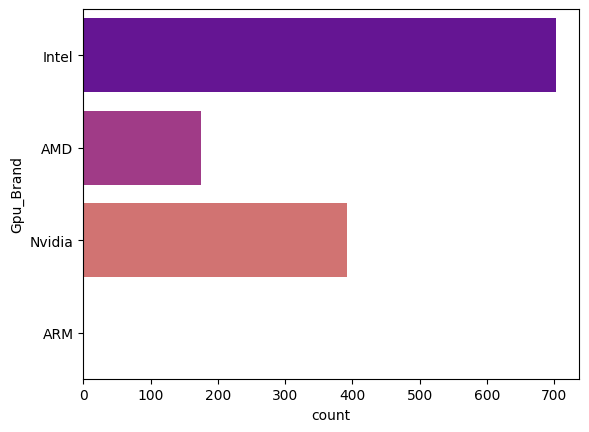

In [558]:
df['Gpu_Brand'] = df['Gpu'].apply(lambda x:x.split()[0])
sn.countplot(df['Gpu_Brand'],palette='plasma')

<Axes: xlabel='count', ylabel='Gpu_Brand'>

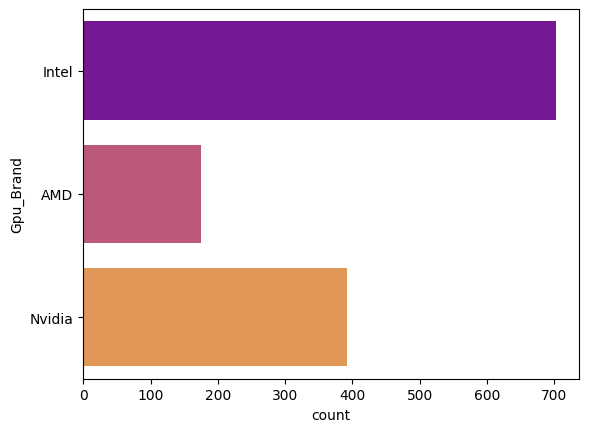

In [559]:
# removing the "ARM" tuple

df = df[df['Gpu_Brand']!='ARM']
sn.countplot(df['Gpu_Brand'],palette='plasma')

In [560]:
df = df.drop('Gpu', axis=1)

In [561]:
df.head(2)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,Intel


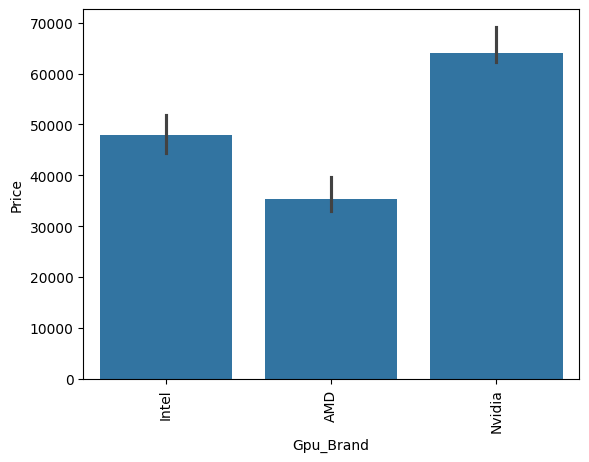

In [562]:
import seaborn as sn
import numpy as np

# Price vs GPU_Brand with median estimator
sn.barplot(x='Gpu_Brand', y='Price', data=df, estimator=np.median)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.show()


# Operating System Analysis

In [563]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0,Intel


In [321]:
df['OpSys'].value_counts()

OpSys
Windows 10      1044
No OS             63
Linux             61
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

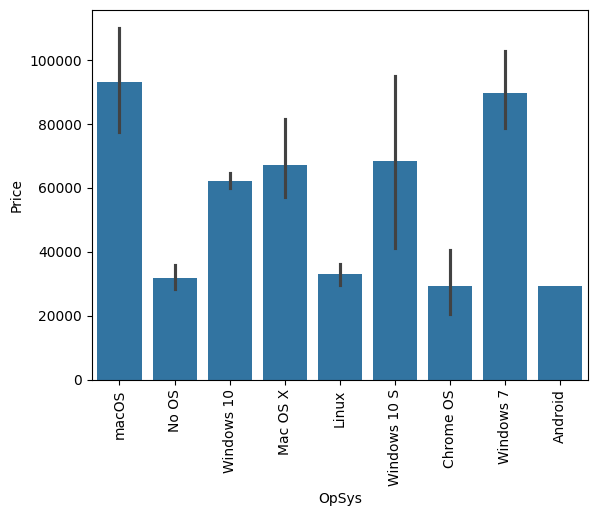

In [564]:
import seaborn as sn
import matplotlib.pyplot as plt

# Use 'data' argument to specify the DataFrame, and 'x' and 'y' for the respective columns
sn.barplot(x='OpSys', y='Price', data=df)

# Rotate x-axis labels for better readability
plt.xticks(rotation='vertical')
plt.show()


In [565]:
df['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux',
       'Windows 10 S', 'Chrome OS', 'Windows 7', 'Android'], dtype=object)

In [566]:
# club {Windows 10, Windows 7, Windows 7S}--> Windows
# club {macOS, macOS X}--> mac
# else return Others

def setcategory(text):
    
    if text == 'Windows 10' or text == 'Windows 7' or text == 'Windows 10 S':
        return 'windows'
    elif text == 'Mac OS X' or text == 'macOS':
        return 'mac'
    else:
        return 'other'
    
df['OpSys'] = df['OpSys'].apply(lambda x:setcategory(x))
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,Apple,Ultrabook,8,mac,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,Intel
1,Apple,Ultrabook,8,mac,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,Intel
2,HP,Notebook,8,other,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0,Intel
3,Apple,Ultrabook,16,mac,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0,AMD
4,Apple,Ultrabook,8,mac,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0,Intel


In [567]:
df.head(2)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,Apple,Ultrabook,8,mac,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,Intel
1,Apple,Ultrabook,8,mac,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,Intel


In [568]:
df.sample(5)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
214,Huawei,Ultrabook,8,windows,1.05,79866.7200,0,1,199.692071,Intel Core i7,512,0,0,Intel
1106,MSI,Gaming,8,windows,2.90,80516.2032,0,0,127.335675,Intel Core i7,128,1024,0,Nvidia
250,Dell,2 in 1 Convertible,8,windows,2.08,43636.3200,1,1,141.211998,Intel Core i7,0,1024,0,Intel
721,HP,2 in 1 Convertible,8,windows,1.58,44574.0480,1,1,117.826530,Intel Core i5,256,0,0,Intel
1074,Lenovo,Ultrabook,8,windows,1.30,91294.7472,1,1,176.232574,Intel Core i7,256,0,0,Intel


<Axes: xlabel='count', ylabel='OpSys'>

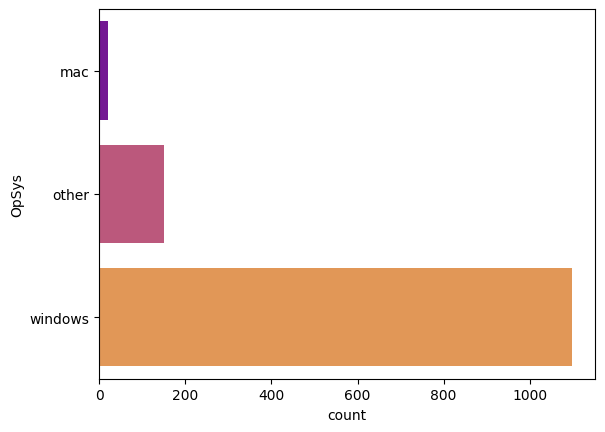

In [569]:
sn.countplot(df['OpSys'],palette='plasma')

([0, 1, 2], [Text(0, 0, 'mac'), Text(1, 0, 'other'), Text(2, 0, 'windows')])

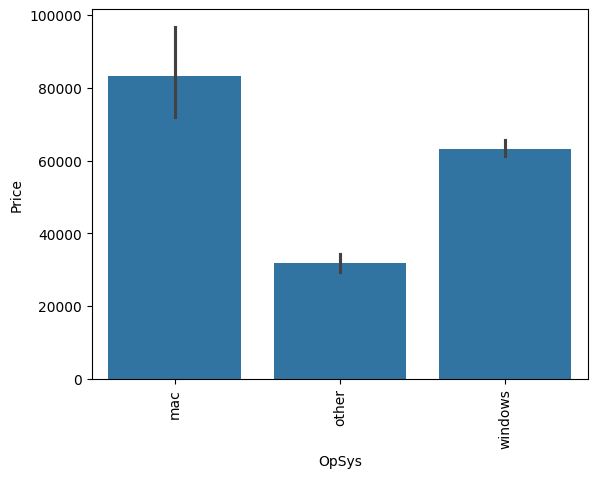

In [570]:
sn.barplot(x = df['OpSys'],y = df['Price'])
plt.xticks(rotation = 'vertical')

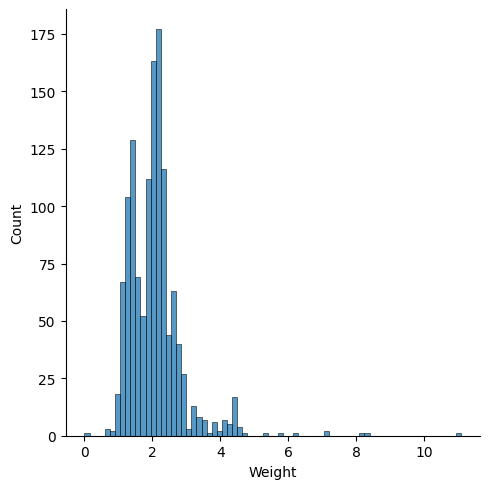

In [571]:
sn.displot(df['Weight'])

# Price Analysis

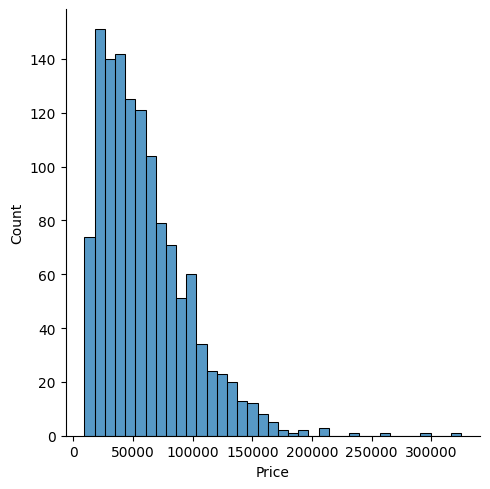

In [572]:
sn.displot(df['Price'])

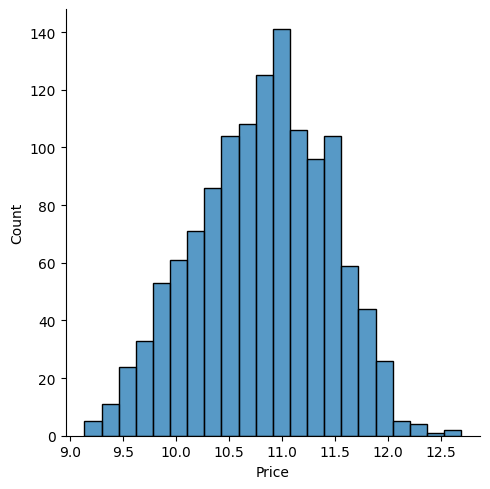

In [573]:
# so if we apply np.log to the Price col we get a Gaussian Distribution

sn.displot(np.log(df['Price']))

# Question: Which features have the most significant impact on laptop prices?

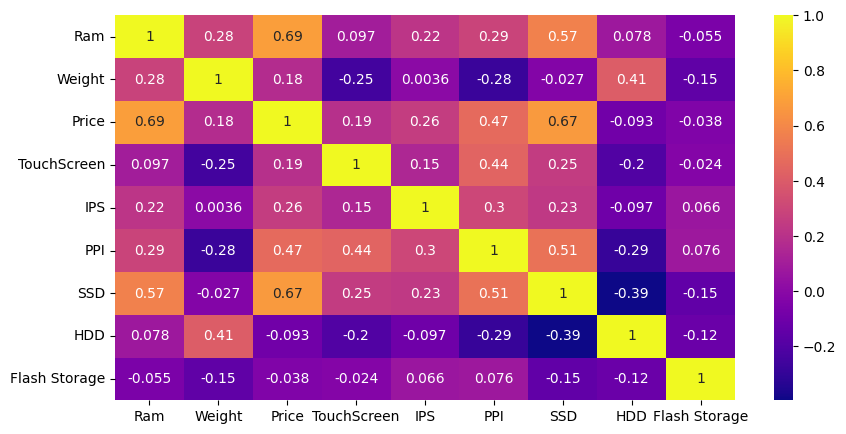

Ram              0.687050
Weight           0.176211
Price            1.000000
TouchScreen      0.191814
IPS              0.257638
PPI              0.471257
SSD              0.668830
HDD             -0.092968
Flash Storage   -0.037656
Name: Price, dtype: float64


In [574]:
# Select only numeric columns before computing correlation
df_numeric = df.select_dtypes(include=[float, int])

# Now calculate the correlation
correlation_matrix = df_numeric.corr()

# Display the heatmap
plt.figure(figsize=(10, 5))
sn.heatmap(correlation_matrix, annot=True, cmap='plasma')
plt.show()

# For price correlation specifically
price_correlation = correlation_matrix['Price']
print(price_correlation)


As RAM has higher cofficient value, we can say that RAM has most significant impact om laptop price

In [578]:
#checking outliers
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1269 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1269 non-null   object 
 1   TypeName       1269 non-null   object 
 2   Ram            1269 non-null   int64  
 3   OpSys          1269 non-null   object 
 4   Weight         1269 non-null   float64
 5   Price          1269 non-null   float64
 6   TouchScreen    1269 non-null   int64  
 7   IPS            1269 non-null   int64  
 8   PPI            1269 non-null   float64
 9   CPU_name       1269 non-null   object 
 10  SSD            1269 non-null   int64  
 11  HDD            1269 non-null   int64  
 12  Flash Storage  1269 non-null   int64  
 13  Gpu_Brand      1269 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 148.7+ KB


In [579]:
num_col = df.select_dtypes(include='number')
cat_col = df.select_dtypes(include = 'object')

In [580]:
num_col

,Ram,Weight,Price,TouchScreen,IPS,PPI,SSD,HDD,Flash Storage
0,8,1.37,71378.6832,0,1,226.983005,128,0,0
1,8,1.34,47895.5232,0,0,127.677940,0,0,128
2,8,1.86,30636.0000,0,0,141.211998,256,0,0
3,16,1.83,135195.3360,0,1,220.534624,512,0,0
4,8,1.37,96095.8080,0,1,226.983005,256,0,0
...,...,...,...,...,...,...,...,...,...
1298,4,1.80,33992.6400,1,1,157.350512,128,0,0
1299,16,1.30,79866.7200,1,1,276.053530,512,0,0
1300,2,1.50,12201.1200,0,0,111.935204,0,0,64
1301,6,2.19,40705.9200,0,0,100.454670,0,1024,0


In [581]:
cat_col

,Company,TypeName,OpSys,CPU_name,Gpu_Brand
0,Apple,Ultrabook,mac,Intel Core i5,Intel
1,Apple,Ultrabook,mac,Intel Core i5,Intel
2,HP,Notebook,other,Intel Core i5,Intel
3,Apple,Ultrabook,mac,Intel Core i7,AMD
4,Apple,Ultrabook,mac,Intel Core i5,Intel
...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,windows,Intel Core i7,Intel
1299,Lenovo,2 in 1 Convertible,windows,Intel Core i7,Intel
1300,Lenovo,Notebook,windows,Other Intel Processer,Intel
1301,HP,Notebook,windows,Intel Core i7,AMD


In [583]:
cat_col.dtypes
for i in cat_col.columns:
    print(f"Column: {i}")
    print(cat_col[i].unique())
    print("\n")
# cat_col['Company'].unique()

Column: Company
['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']


Column: TypeName
['Ultrabook' 'Notebook' 'Gaming' '2 in 1 Convertible' 'Workstation'
 'Netbook']


Column: OpSys
['mac' 'other' 'windows']


Column: CPU_name
['Intel Core i5' 'Intel Core i7' 'AMD Processer' 'Intel Core i3'
 'Other Intel Processer']


Column: Gpu_Brand
['Intel' 'AMD' 'Nvidia']




In [602]:
#split the categorical and numerical columns
num_col = df.select_dtypes(include='number')
cat_col = df.select_dtypes(include = 'object')                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     #converting all categorical data into lower case
cat_col
#convert categorical data into lower case
for col in cat_col:
    df[col] = df[col].str.lower()
cat_col

,Company,TypeName,OpSys,CPU_name,Gpu_Brand
0,Apple,Ultrabook,mac,Intel Core i5,Intel
1,Apple,Ultrabook,mac,Intel Core i5,Intel
2,HP,Notebook,other,Intel Core i5,Intel
3,Apple,Ultrabook,mac,Intel Core i7,AMD
4,Apple,Ultrabook,mac,Intel Core i5,Intel
...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,windows,Intel Core i7,Intel
1299,Lenovo,2 in 1 Convertible,windows,Intel Core i7,Intel
1300,Lenovo,Notebook,windows,Other Intel Processer,Intel
1301,HP,Notebook,windows,Intel Core i7,AMD


In [360]:
num_col

,Ram,Weight,Price,TouchScreen,IPS,PPI,SSD,HDD,Flash Storage
0,8,1.37,71378.6832,0,1,226.983005,128,0,0
1,8,1.34,47895.5232,0,0,127.677940,0,0,128
2,8,1.86,30636.0000,0,0,141.211998,256,0,0
3,16,1.83,135195.3360,0,1,220.534624,512,0,0
4,8,1.37,96095.8080,0,1,226.983005,256,0,0
...,...,...,...,...,...,...,...,...,...
1298,4,1.80,33992.6400,1,1,157.350512,128,0,0
1299,16,1.30,79866.7200,1,1,276.053530,512,0,0
1300,2,1.50,12201.1200,0,0,111.935204,0,0,64
1301,6,2.19,40705.9200,0,0,100.454670,0,1024,0


# Model Building

In [603]:
df.columns

Index(['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'Price', 'TouchScreen',
       'IPS', 'PPI', 'CPU_name', 'SSD', 'HDD', 'Flash Storage', 'Gpu_Brand'],
      dtype='object')

In [604]:
df.head(2)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,apple,ultrabook,8,mac,1.37,71378.6832,0,1,226.983005,intel core i5,128,0,0,intel
1,apple,ultrabook,8,mac,1.34,47895.5232,0,0,127.677940,intel core i5,0,0,128,intel


In [605]:
test = df['Price']
train = df.drop(['Price'],axis=1)

In [606]:
test

0        71378.6832
1        47895.5232
2        30636.0000
3       135195.3360
4        96095.8080
           ...     
1298     33992.6400
1299     79866.7200
1300     12201.1200
1301     40705.9200
1302     19660.3200
Name: Price, Length: 1269, dtype: float64

In [365]:
train

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,apple,ultrabook,8,mac,1.37,0,1,226.983005,intel core i5,128,0,0,intel
1,apple,ultrabook,8,mac,1.34,0,0,127.677940,intel core i5,0,0,128,intel
2,hp,notebook,8,other,1.86,0,0,141.211998,intel core i5,256,0,0,intel
3,apple,ultrabook,16,mac,1.83,0,1,220.534624,intel core i7,512,0,0,amd
4,apple,ultrabook,8,mac,1.37,0,1,226.983005,intel core i5,256,0,0,intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,lenovo,2 in 1 convertible,4,windows,1.80,1,1,157.350512,intel core i7,128,0,0,intel
1299,lenovo,2 in 1 convertible,16,windows,1.30,1,1,276.053530,intel core i7,512,0,0,intel
1300,lenovo,notebook,2,windows,1.50,0,0,111.935204,other intel processer,0,0,64,intel
1301,hp,notebook,6,windows,2.19,0,0,100.454670,intel core i7,0,1024,0,amd


In [607]:
df.to_csv('laptop_cleaned.csv', index=False)

In [609]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1269 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1269 non-null   object 
 1   TypeName       1269 non-null   object 
 2   Ram            1269 non-null   int64  
 3   OpSys          1269 non-null   object 
 4   Weight         1269 non-null   float64
 5   Price          1269 non-null   float64
 6   TouchScreen    1269 non-null   int64  
 7   IPS            1269 non-null   int64  
 8   PPI            1269 non-null   float64
 9   CPU_name       1269 non-null   object 
 10  SSD            1269 non-null   int64  
 11  HDD            1269 non-null   int64  
 12  Flash Storage  1269 non-null   int64  
 13  Gpu_Brand      1269 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 148.7+ KB


In [610]:
num_col = df.select_dtypes(include='number')

In [611]:
num_col

,Ram,Weight,Price,TouchScreen,IPS,PPI,SSD,HDD,Flash Storage
0,8,1.37,71378.6832,0,1,226.983005,128,0,0
1,8,1.34,47895.5232,0,0,127.677940,0,0,128
2,8,1.86,30636.0000,0,0,141.211998,256,0,0
3,16,1.83,135195.3360,0,1,220.534624,512,0,0
4,8,1.37,96095.8080,0,1,226.983005,256,0,0
...,...,...,...,...,...,...,...,...,...
1298,4,1.80,33992.6400,1,1,157.350512,128,0,0
1299,16,1.30,79866.7200,1,1,276.053530,512,0,0
1300,2,1.50,12201.1200,0,0,111.935204,0,0,64
1301,6,2.19,40705.9200,0,0,100.454670,0,1024,0


In [612]:
df.columns

Index(['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'Price', 'TouchScreen',
       'IPS', 'PPI', 'CPU_name', 'SSD', 'HDD', 'Flash Storage', 'Gpu_Brand'],
      dtype='object')

In [613]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree

In [614]:
X_train, X_test, y_train, y_test = train_test_split(train,test, test_size=0.15,random_state=42)
X_train.shape, X_test.shape

((1078, 13), (191, 13))

In [615]:
X_train.columns

Index(['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'TouchScreen', 'IPS',
       'PPI', 'CPU_name', 'SSD', 'HDD', 'Flash Storage', 'Gpu_Brand'],
      dtype='object')

In [616]:
X_train.to_csv('X_train.csv', index=False)

In [617]:
X_train.head(2)

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
684,lenovo,2 in 1 convertible,8,windows,1.19,1,1,165.632118,intel core i7,512,0,0,intel
982,lenovo,notebook,6,windows,2.20,0,0,141.211998,amd processer,256,0,0,amd


**There's a CLass which we imported named as Column Transformer we use this widely while building our models using Pipelines, so for this we have to get the index numbers of the columns which are having categorical variables**

In [618]:
# mapper = {i:value for i, value in enumerate(X_train.columns)}
# # mapper

In [619]:
X_train.columns

Index(['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'TouchScreen', 'IPS',
       'PPI', 'CPU_name', 'SSD', 'HDD', 'Flash Storage', 'Gpu_Brand'],
      dtype='object')

In [620]:
num_col = num_col.drop(columns=['Price'])

In [621]:
num_col

,Ram,Weight,TouchScreen,IPS,PPI,SSD,HDD,Flash Storage
0,8,1.37,0,1,226.983005,128,0,0
1,8,1.34,0,0,127.677940,0,0,128
2,8,1.86,0,0,141.211998,256,0,0
3,16,1.83,0,1,220.534624,512,0,0
4,8,1.37,0,1,226.983005,256,0,0
...,...,...,...,...,...,...,...,...
1298,4,1.80,1,1,157.350512,128,0,0
1299,16,1.30,1,1,276.053530,512,0,0
1300,2,1.50,0,0,111.935204,0,0,64
1301,6,2.19,0,0,100.454670,0,1024,0


In [622]:
cat_col = df.select_dtypes(include = 'object')

In [625]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [626]:
X_train

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
684,lenovo,2 in 1 convertible,8,windows,1.19,1,1,165.632118,intel core i7,512,0,0,intel
982,lenovo,notebook,6,windows,2.20,0,0,141.211998,amd processer,256,0,0,amd
1241,asus,ultrabook,8,windows,1.45,0,0,165.632118,intel core i7,256,0,0,intel
477,lenovo,notebook,8,windows,1.70,0,0,157.350512,intel core i5,180,0,0,intel
459,hp,notebook,8,windows,2.50,0,0,106.113062,intel core i3,256,0,0,intel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,lenovo,notebook,8,windows,3.00,0,0,106.113062,intel core i5,0,1024,0,amd
1126,lenovo,2 in 1 convertible,4,windows,0.69,1,1,224.173809,other intel processer,0,0,64,intel
1161,msi,gaming,16,windows,1.70,0,0,157.350512,intel core i7,256,1024,0,nvidia
885,hp,2 in 1 convertible,4,windows,1.28,1,0,165.632118,intel core i5,256,0,0,intel


In [627]:
print(type(num_col))

<class 'pandas.core.frame.DataFrame'>


In [629]:
print(X_train.columns)
print(num_col.columns)
print(cat_col.columns)

Index(['Company', 'TypeName', 'Ram', 'OpSys', 'Weight', 'TouchScreen', 'IPS',
       'PPI', 'CPU_name', 'SSD', 'HDD', 'Flash Storage', 'Gpu_Brand'],
      dtype='object')
Index(['Ram', 'Weight', 'TouchScreen', 'IPS', 'PPI', 'SSD', 'HDD',
       'Flash Storage'],
      dtype='object')
Index(['Company', 'TypeName', 'OpSys', 'CPU_name', 'Gpu_Brand'], dtype='object')


In [630]:
cat_col = df.select_dtypes(include='object').columns.tolist()
num_col = df.select_dtypes(include='number').columns.tolist()

In [631]:
num_col

['Ram',
 'Weight',
 'Price',
 'TouchScreen',
 'IPS',
 'PPI',
 'SSD',
 'HDD',
 'Flash Storage']

In [632]:
#drop price column
num_col = ['Ram',
 'Weight',
 'TouchScreen',
 'IPS',
 'PPI',
 'SSD',
 'HDD',
 'Flash Storage']

In [633]:
mapper = {i:value for i,value in enumerate(X_train.columns)}
mapper

{0: 'Company',
 1: 'TypeName',
 2: 'Ram',
 3: 'OpSys',
 4: 'Weight',
 5: 'TouchScreen',
 6: 'IPS',
 7: 'PPI',
 8: 'CPU_name',
 9: 'SSD',
 10: 'HDD',
 11: 'Flash Storage',
 12: 'Gpu_Brand'}

# Model Building

In [634]:
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
# Add an imputer before OneHotEncoder

#num_col and cat_col is the list of columns in the dataframe

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
                         ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('scale', StandardScaler())])

col_transformer = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipe, [2,4,7,9,10,11]),
    ('cat_pipeline', cat_pipe, cat_col)],
    remainder='passthrough')


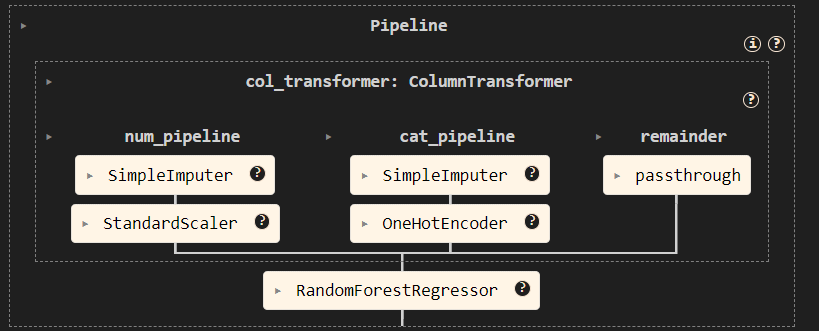

In [635]:
rf = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)
final_pipeline = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', rf)])
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('col_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  [2, 4, 7, 9, 10, 11]),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Company', 'TypeName',
                                                   'OpSys', 'CPU_name',
                                                   'Gpu_Brand'])])),
                ('estimator',
                 RandomForestRegressor(max_depth=15, max_features=0.75,
                                       max_samples=0.5, random_state=3))])

In [636]:
import pickle

with open('model_pipeline.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)


In [637]:
import pickle
import numpy as np

# Load the trained pipeline
with open('model_pipeline.pkl', 'rb') as file:
    loaded_pipe = pickle.load(file)

# Prepare user input as a 2D array matching the feature order expected by the pipeline
user_input = pd.DataFrame([{
    'Ram': 8,
    'Weight': 1.0,
    'PPI': 120,
    'HDD': 1024,
    'SSD': 0,
    'Flash Storage': 0,
    'Company': 'Dell',
    'TypeName': 'Notebook',
    'OpSys': 'Windows',
    'CPU_name': 'Intel Core i7',
    'Gpu_Brand': 'Intel',
    'TouchScreen': 0,
    'IPS': 1
}])
# Make prediction
prediction = loaded_pipe.predict(user_input)

print('Predicted value:', prediction)


Predicted value: [59975.496912]


# Random Forest

In [638]:
rf = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)
final_pipeline = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', rf)])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

print('R2 score',metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

R2 score 0.8260531986577784
MAE 8352.006627422952


# Linear Regression

In [639]:
lr = LinearRegression()
final_pipeline = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', lr)])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
print('R2 score',metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

R2 score 0.6710237101179881
MAE 11740.364990895394


# Ridge Regression

In [640]:
ridge_r = Ridge(alpha=10)
final_pipeline = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', ridge_r)])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
print('R2 score',metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

R2 score 0.6505377871770621
MAE 12132.435082959046


# Lasso Regression

In [641]:
lasso_r = Lasso(alpha=0.1)
final_pipeline = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', lasso_r)])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
print('R2 score',metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

R2 score 0.6710154020932388
MAE 11741.286110737072


# Decision Tree

In [642]:
dt_r = DecisionTreeRegressor(random_state=42)
final_pipeline = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', dt_r)])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
print('R2 score',metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

R2 score 0.7306049487341126
MAE 9888.509968586388


# Gradient Boosting Regressor


In [643]:
gd_b = GradientBoostingRegressor(random_state=42)
final_pipe_grad = Pipeline(steps = [('col_transformer', col_transformer), ('estimator', gd_b)])
final_pipe_grad.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
print('R2 score',metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

R2 score 0.7306049487341126
MAE 9888.509968586388


# Pickling the ML pipeline and the data

In [644]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(final_pipeline, open('pipe.pkl','wb'))

In [645]:
train.head()


,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand
0,apple,ultrabook,8,mac,1.37,0,1,226.983005,intel core i5,128,0,0,intel
1,apple,ultrabook,8,mac,1.34,0,0,127.677940,intel core i5,0,0,128,intel
2,hp,notebook,8,other,1.86,0,0,141.211998,intel core i5,256,0,0,intel
3,apple,ultrabook,16,mac,1.83,0,1,220.534624,intel core i7,512,0,0,amd
4,apple,ultrabook,8,mac,1.37,0,1,226.983005,intel core i5,256,0,0,intel


In [646]:
train.to_csv('traineddata.csv',index=None)

In [647]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Auto-detect categorical and numerical columns from your training DataFrame
cat_col = X_train.select_dtypes(include='object').columns.tolist()
num_col = ['Ram',
 'Weight',
 'PPI',
 'SSD',
 'HDD',
 'Flash Storage']

# Pipeline for numerical features: impute missing values and scale
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # or 'median'
    ('scaler', StandardScaler())
])

# Pipeline for categorical features: impute missing values and one-hot encode
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine the pipelines into a ColumnTransformer
col_transformer = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipe, num_col),
    ('cat_pipeline', cat_pipe, cat_col)
], remainder='passthrough')  # Optional: keep any extra columns


models = {
    'Linear Regression': (LinearRegression(), {}),  # No hyperparams to tune
    'Ridge Regression': (Ridge(), {'alpha': [0.1, 1.0, 10.0]}),
    'Lasso': (Lasso(), {'alpha': [1.0]}),
    'Random Forest': (RandomForestRegressor(random_state=42), {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    }),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42), {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }),
    'Decision Tree': (DecisionTreeRegressor(random_state=42), {
        'max_depth': [None, 5, 10],
})
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

Evaluation on RMSE

In [648]:
best_model_result = None  # To store best model's name, score, and pipeline
lowest_score = float('inf')  # Initialize with a very high value

for model_name, (model, param_grid) in models.items():
    # Build the pipeline
    pipeline = Pipeline([
        ('preprocessing', col_transformer),
        ('regressor', model)
    ])

    if param_grid:
        # Adjust param grid keys for pipeline
        param_grid = {f'regressor__{key}': value for key, value in param_grid.items()}

        grid_search = GridSearchCV(pipeline, param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_score = -grid_search.best_score_  # Convert to positive RMSE
        best_model = grid_search.best_estimator_
    else:
        best_model = pipeline.fit(X_train, y_train)
        best_score = mean_squared_error(y_test, best_model.predict(X_test))  # RMSE

    # Keep only the best-performing model
    if best_score < lowest_score:
        lowest_score = best_score
        best_model_result = (model_name, best_score, best_model)

# Final best model info
model_name, score, final_model = best_model_result
print(f"✅ Best Model: {model_name}")
print(f"📉 Best RMSE: {score:.4f}")


✅ Best Model: Gradient Boosting
📉 Best RMSE: 17003.0333


Evaluatoion on R2-Score

In [649]:
from sklearn.metrics import r2_score  # Import R² score

best_model_result = None  # To store best model's name, score, and pipeline
best_r2_score = -float('inf')  # Initialize with a very low value for R² (since higher R² is better)

for model_name, (model, param_grid) in models.items():
    # Build the pipeline
    pipeline = Pipeline([
        ('preprocessing', col_transformer),
        ('regressor', model)
    ])

    if param_grid:
        # Adjust param grid keys for pipeline
        param_grid = {f'regressor__{key}': value for key, value in param_grid.items()}

        grid_search = GridSearchCV(pipeline, param_grid, cv=kf, scoring='r2')  # Use 'r2' scoring
        grid_search.fit(X_train, y_train)
        best_score = grid_search.best_score_  # This is now R² score
        best_model = grid_search.best_estimator_
    else:
        best_model = pipeline.fit(X_train, y_train)
        # Calculate R² score on test data
        best_score = r2_score(y_test, best_model.predict(X_test))

    # Keep only the best-performing model (highest R² score)
    if best_score > best_r2_score:
        best_r2_score = best_score
        best_model_result = (model_name, best_score, best_model)

# Final best model info
model_name, score, final_model = best_model_result
print(f"✅ Best Model: {model_name}")
print(f"📈 Best R² Score: {score:.4f}")


✅ Best Model: Gradient Boosting
📈 Best R² Score: 0.7958


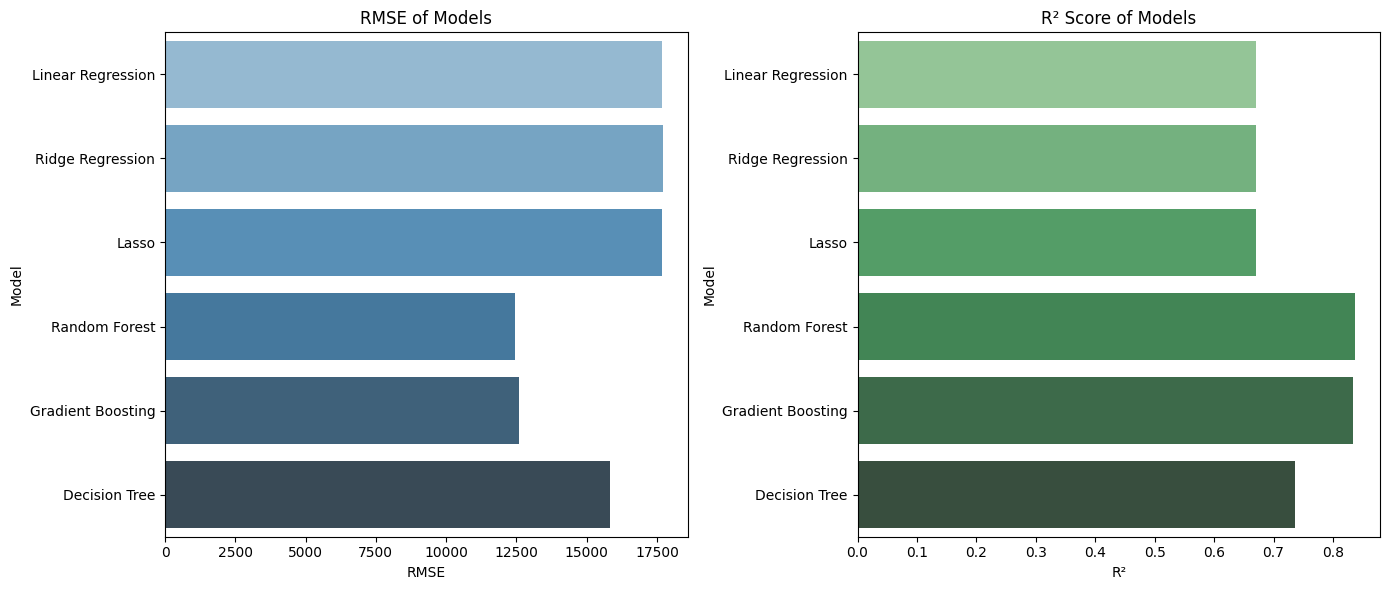

In [442]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# Initialize lists to store model names, RMSE, and R² scores
model_names = []
rmse_scores = []
r2_scores = []

# Loop through models and evaluate RMSE and R²
for model_name, (model, param_grid) in models.items():
    # Build the pipeline
    pipeline = Pipeline([
        ('preprocessing', col_transformer),
        ('regressor', model)
    ])

    if param_grid:
        param_grid = {f'regressor__{key}': value for key, value in param_grid.items()}
        grid_search = GridSearchCV(pipeline, param_grid, cv=kf, scoring='neg_root_mean_squared_error')
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        # Calculate RMSE and R² on test data
        y_pred = best_model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
    else:
        best_model = pipeline.fit(X_train, y_train)
        # Calculate RMSE and R² on test data
        y_pred = best_model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

    # Append results
    model_names.append(model_name)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

# Create a DataFrame to hold the results for better visualization
import pandas as pd
results_df = pd.DataFrame({
    'Model': model_names,
    'RMSE': rmse_scores,
    'R²': r2_scores
})

# Visualize the results using matplotlib and seaborn
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# RMSE Bar Plot
sns.barplot(x='RMSE', y='Model', data=results_df, ax=ax[0], palette='Blues_d')
ax[0].set_title('RMSE of Models')

# R² Bar Plot
sns.barplot(x='R²', y='Model', data=results_df, ax=ax[1], palette='Greens_d')
ax[1].set_title('R² Score of Models')

plt.tight_layout()
plt.show()


# Prediction on Best Model: Gradient Boosting

In [651]:
# Fit the gardient boosing pipeline to the entire dataset
final_pipe_grad.fit(X_train, y_train)

# Predict on the whole dataset (or a new dataset)
y_pred = final_pipe_grad.predict(X_test)

# Output predicted prices
print("Predicted Prices:", y_pred)

# Evaluate performance (optional, if you have true values to compare)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

Predicted Prices: [ 86976.56261206  18753.38153144  81197.22251335  38449.74203225
  30003.67367472  84137.85882082  71670.043378    78544.14644099
  47157.40624556  59431.71281143  22282.41546114  18723.00926694
  70961.11396628  59589.91586588  43610.13925806  25844.75062388
  22350.21517069  93726.70395985  34558.34417002  17339.85024924
  30840.49902105  38169.33727717  13524.82483139  63552.60670212
  44273.11277788  59431.71281143  32652.90689928  77571.88285999
  29919.79889011  20752.54915922  23747.77363524  19611.89656473
  49285.34843954  42730.66779698  78313.12893104  56022.53823711
  13524.82483139  12989.18410514  36008.61061059  72190.64124302
  44245.50841619  68254.10736127  65830.12168291  61530.20498058
  28953.48821685  24294.97670395 152859.25717116  18769.7878162
 105854.93926213 102188.02494452  55217.04282187  89416.29502646
  85561.19949097  24294.97670395  18290.21287205  13321.2416058
  65314.24335681  41081.64785132  23528.92674971  50140.99383978
  26977.9

# Prediction on Whole Dataset

In [652]:
predicted = final_pipe_grad.predict(train)

In [653]:
predicted

array([74657.02817052, 60037.46232945, 45207.77949506, ...,
       18121.93966201, 36624.29351499, 19116.38840089], shape=(1269,))

In [654]:
df['Predicted Price'] = predicted

In [655]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_name,SSD,HDD,Flash Storage,Gpu_Brand,Predicted Price
0,apple,ultrabook,8,mac,1.37,71378.6832,0,1,226.983005,intel core i5,128,0,0,intel,74657.028171
1,apple,ultrabook,8,mac,1.34,47895.5232,0,0,127.677940,intel core i5,0,0,128,intel,60037.462329
2,hp,notebook,8,other,1.86,30636.0000,0,0,141.211998,intel core i5,256,0,0,intel,45207.779495
3,apple,ultrabook,16,mac,1.83,135195.3360,0,1,220.534624,intel core i7,512,0,0,amd,129117.113674
4,apple,ultrabook,8,mac,1.37,96095.8080,0,1,226.983005,intel core i5,256,0,0,intel,83681.524195


# Visualizing the prediction vs actual

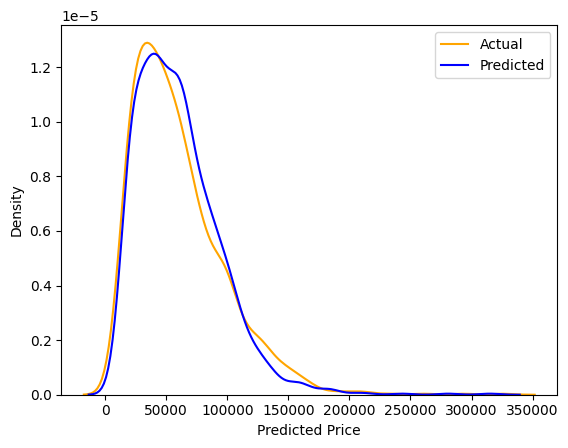

In [656]:
sn.distplot(df['Price'],hist=False,color='orange',label='Actual')
sn.distplot(df['Predicted Price'],hist=False,color='blue',label='Predicted')
plt.legend()
plt.show()

In [657]:
import pickle
file = open('model_pipeline.pkl','wb')
pickle.dump(final_pipe_grad,file)
file.close()